In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
)

from aind_hcr_qc.viz.spot_detection import (
    annotate_spots_df,
    plot_removal_metric_distributions,
)
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "782149"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")
OUTPUT_DIR = Path(f"/root/capsule/scratch/single_cell_unmixing/{MOUSE_ID}")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=DATA_DIR / pairwise_asset_name,
        source_dataset=dataset,   # delegates zarr / segmentation calls
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-04-15_21-20-31  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['unmixe

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R1: no unmixed_spots_R1*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R1: no mixed_spots_R1.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


[DEBUG get_spot_files] .pkl files in folder: ['unmixed_spots_R-1_minDist_3.pkl', 'mixed_spots_R-1.pkl', 'mixed_spots_R4.pkl', 'unmixed_spots_R4_minDist_3.pkl']
[DEBUG get_spot_files] unmixed_spots=/root/capsule/data/HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35/image_spot_spectral_unmixing/unmixed_spots_R4_minDist_3.pkl  mixed_spots=/root/capsule/data/HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35/image_spot_spectral_unmixing/mixed_spots_R4.pkl
[DEBUG get_spot_files] key=R5 round_num=5
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing exists=True
[DEBUG get_spot_files] .pkl files in folder: ['unmixed_spots_R5_minDist_3.pkl', 'mixed_spots_R-1.pkl', 'mixed_spots_R5.pkl', 'unmixed_spots_R-1_minDist_3.pkl']
[DEBUG get_spot_files] unmixed_spots=/root/capsule/data/HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26/image_spot_spectral_unmixing/unmixed_spots_R5_m

FileNotFoundError: No round sub-folders matching '782149_R{N}' found in /root/capsule/data/HCR_782149_pairwise-unmixing_2026-04-15_21-20-31

In [ ]:

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

# ── load spots (both tables) for this cell ───────────────────────────────────
mixed_all   = pw_ds.load_all_rounds_spots_mp(table_type="mixed_spots",   remove_fg_bg_cols=True)
unmixed_all = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=True)




Loading mixed_spots for round R1: 782149_R1
Loading mixed_spots for round R2: 782149_R2
Loading mixed_spots for round R3: 782149_R3

Loading mixed_spots for round R5: 782149_R5

Loading mixed_spots for round R4: 782149_R4



Number of mixed_spots: 3.628e+07
Loading unmixed_spots for round R1: 782149_R1
Loading unmixed_spots for round R2: 782149_R2


Loading unmixed_spots for round R3: 782149_R3
Loading unmixed_spots for round R4: 782149_R4
Loading unmixed_spots for round R5: 782149_R5



Number of unmixed_spots: 2.927e+07


In [5]:
mixed_all, unmixed_all = annotate_spots_df(mixed_all, unmixed_all)

print(f"unmixed_all: {unmixed_all['reassigned'].sum():,} reassigned spots "
      f"({100 * unmixed_all['reassigned'].mean():.1f}%)")
print(f"mixed_all  : {mixed_all['removed'].sum():,} removed spots "
      f"({100 * mixed_all['removed'].mean():.1f}%)")


NameError: name 'mixed_all' is not defined

In [6]:
dataset.rounds["R1"].spot_channels

['488', '561']

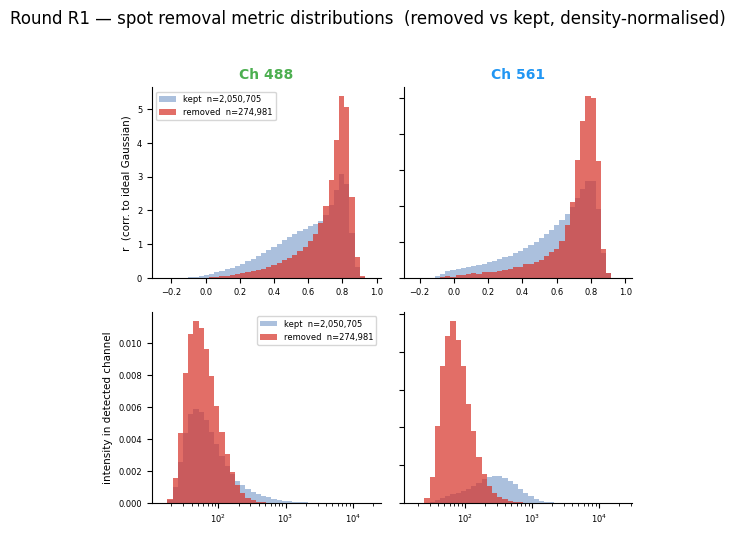

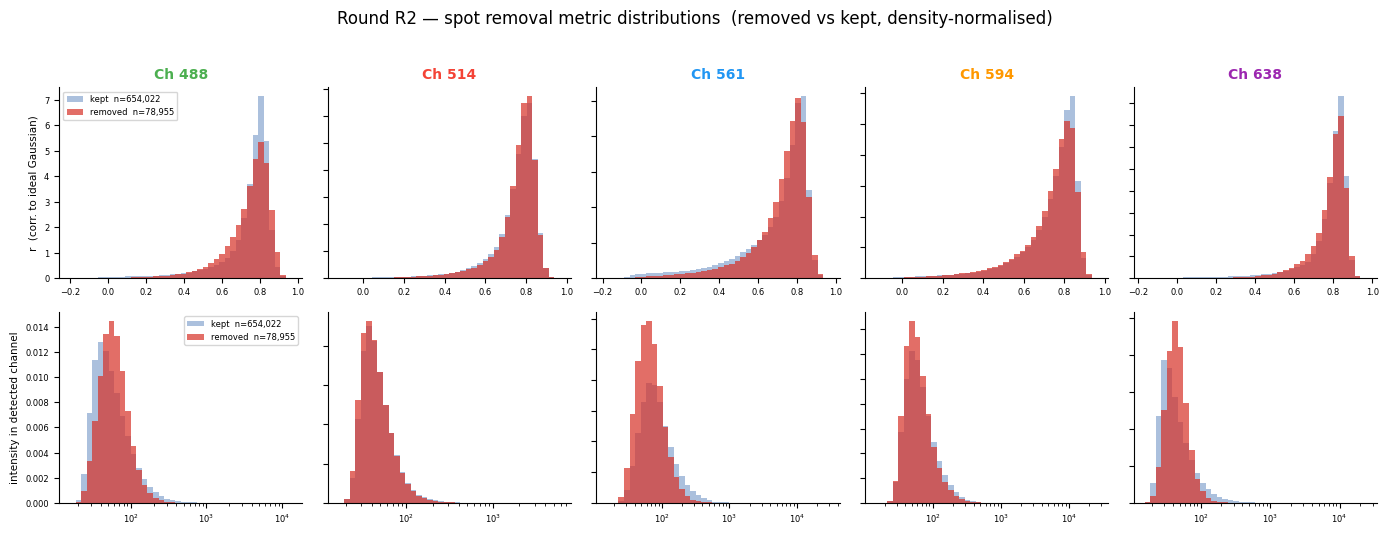

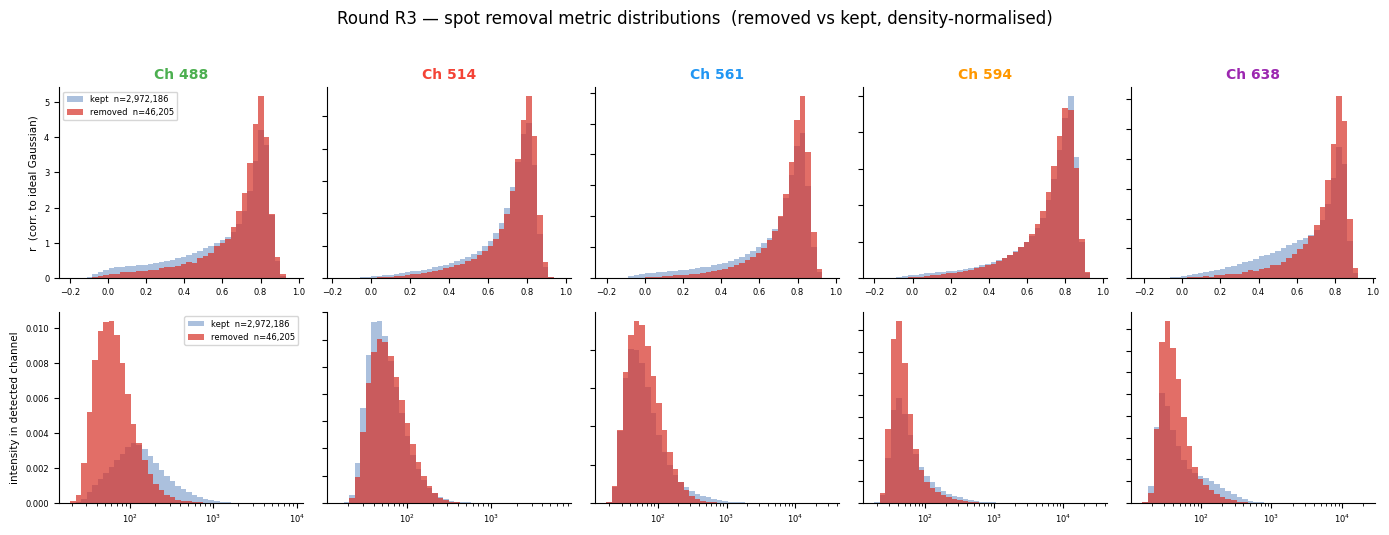

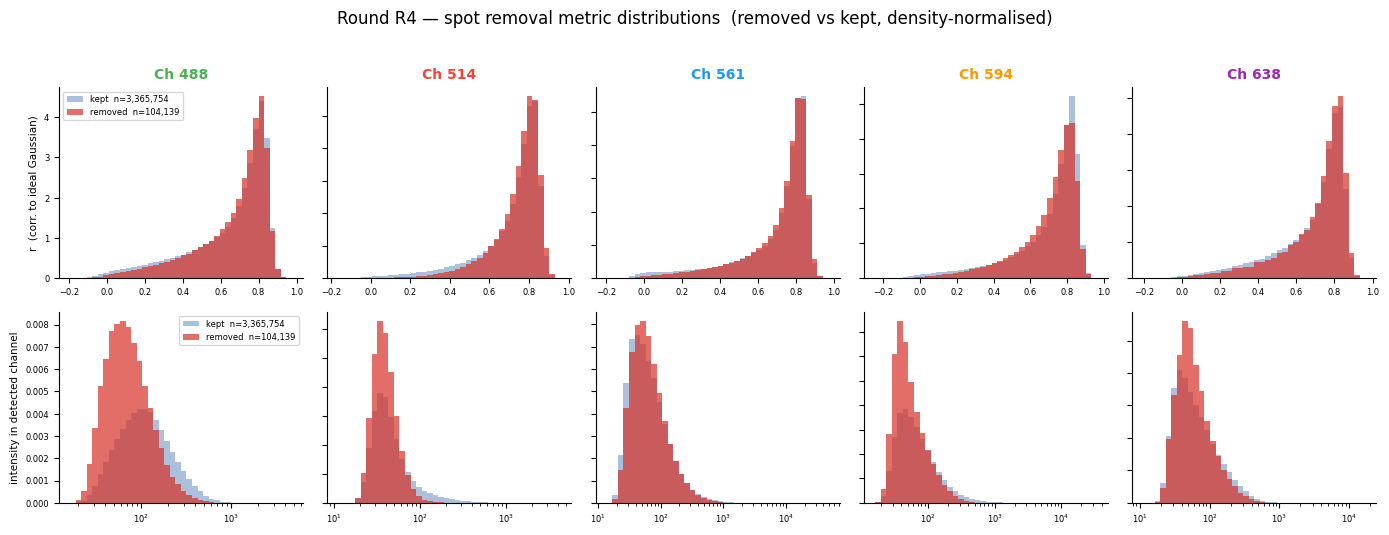

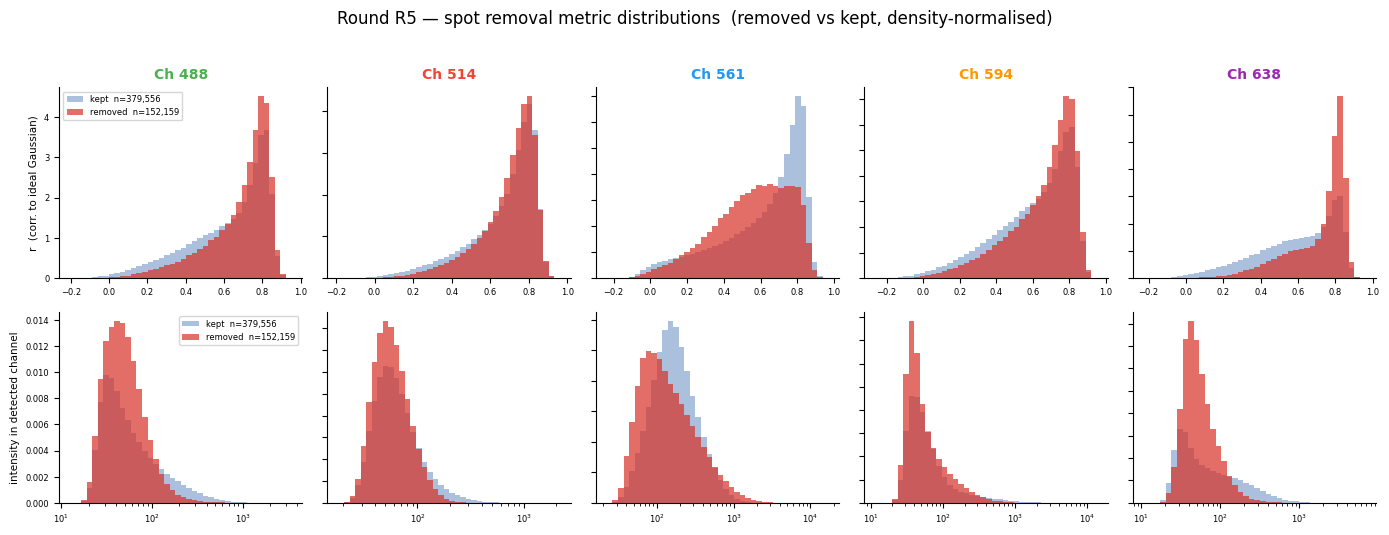

In [7]:
#round_key = "R5"
rounds = ["R1","R2","R3","R4","R5"]
for round_key in rounds:
    CHAN_ORDER = dataset.rounds[round_key].spot_channels
    save_kwargs = {"save": True, 
                    "output_dir": OUTPUT_DIR, 
                    "filename": f"removal_kept_dist_{round_key}"}
    plot_removal_metric_distributions(mixed_all, round_id=round_key, 
                                    chan_order=CHAN_ORDER,
                                    chan_colors=CHAN_COLORS,
                                    **save_kwargs)

In [8]:
from aind_hcr_qc.viz.spot_detection import (
    compute_spot_crosstalk_scores_intensity,
    plot_crosstalk_scores_intensity,
    #compute_dye_line_distances_numpy
)

In [9]:
round_key = "R5"

In [10]:
ratios_df = pw_ds.rounds[round_key].load_ratios_matrix()
unmixed_spots_round = unmixed_all[(unmixed_all["round"] == round_key)]
unmixed_spots_scored = compute_spot_crosstalk_scores_intensity(
    unmixed_spots_round, mixed_all, ratios_df,
    round_id=round_key, chan_order=CHAN_ORDER,
    w_ratio=1.0,
    w_dim=1.0,
    z_keep_threshold=12,
)

  z_keep_threshold=12: 141724 spots vetoed (score → 0)


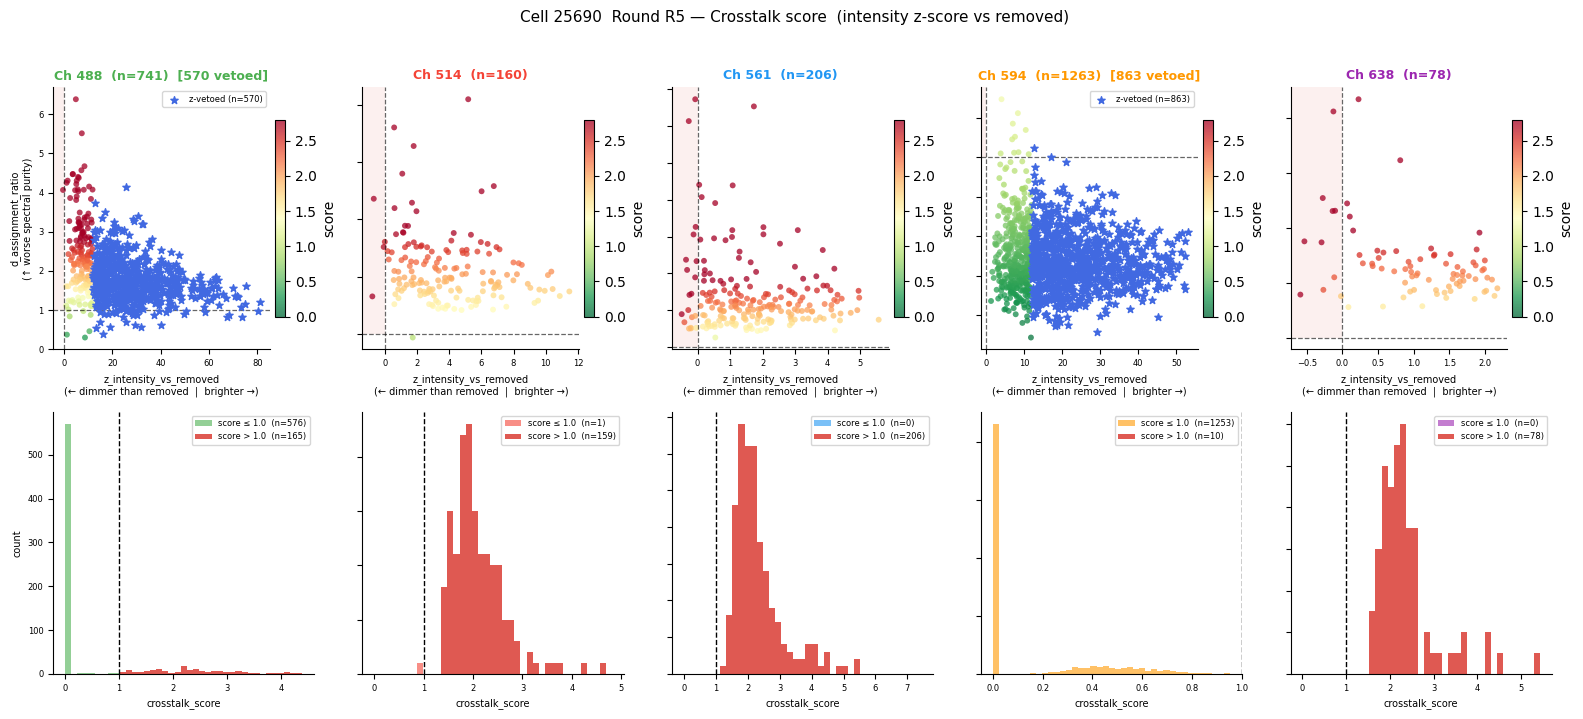


   Ch       n   med_ratio   med_z_int   med_score   % score>1
  488     741       1.765       22.53       0.000       22.3%
  514     160       1.959        3.48       1.968       99.4%
  561     206       2.109        1.54       2.136      100.0%
  594    1263       0.462       17.12       0.000        0.8%
  638      78       2.198        1.11       2.232      100.0%


In [ ]:
# check single cell
CELL_ID = 25690
cell_spots = unmixed_spots_scored[unmixed_spots_scored["cell_id"]==25690]

plot_crosstalk_scores_intensity(
    cell_spots, round_id=round_key, cell_id=CELL_ID,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
)

## plot dist of many cells

In [11]:
unmixed_spots_scored.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'unmixed_gene', 'mixed_gene',
       'chan_514_intensity', 'chan_638_intensity', 'reassigned', 'd_488',
       'd_514', 'd_561', 'd_594', 'd_638', 'dist_r_np', 'd_assignment_ratio',
       'chan_intensity', 'z_intensity_vs_removed', 'z_vetoed',
       'crosstalk_score'],
      dtype='str')

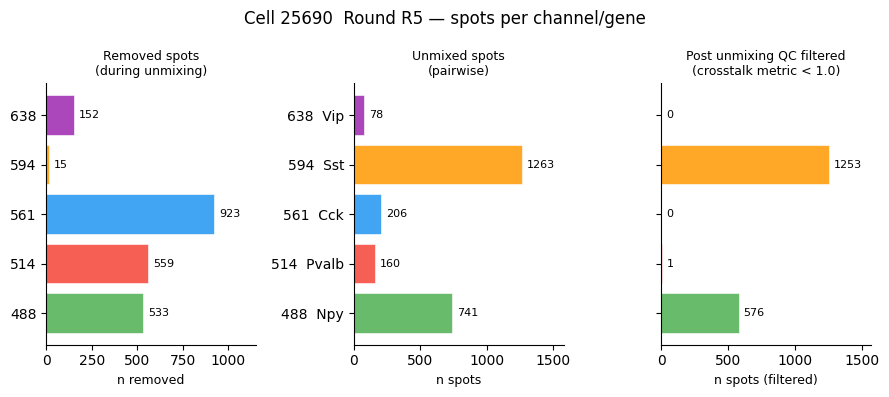

In [20]:

# --- Bar chart: removed | all unmixed | crosstalk-filtered, per chan(/gene) ---
CELL_ID = 25690
CROSSTALK_THRESH = 1.0

# ── mixed spots: removed per channel ────────────────────────────────────────
mixed_cell = mixed_all[
    (mixed_all["cell_id"] == CELL_ID) & (mixed_all["round"] == round_key)
].copy()
removed_counts = (
    mixed_cell[mixed_cell["removed"] == True]
    .groupby("chan").size()
    .reindex(CHAN_ORDER, fill_value=0)
)
removed_bar_colors = [CHAN_COLORS.get(ch, "grey") for ch in CHAN_ORDER]

# ── unmixed spots: all and crosstalk-filtered ────────────────────────────────
cell_df = unmixed_spots_scored[unmixed_spots_scored["cell_id"] == CELL_ID].copy()
cell_df["label"] = cell_df["unmixed_chan"].astype(str) + "  " + cell_df["unmixed_gene"].astype(str)

label_order = []
for ch in CHAN_ORDER:
    labels_for_ch = sorted(cell_df.loc[cell_df["unmixed_chan"] == ch, "label"].unique())
    label_order.extend(labels_for_ch)

counts_all  = cell_df.groupby("label").size().reindex(label_order, fill_value=0)
counts_filt = (
    cell_df[cell_df["crosstalk_score"] < CROSSTALK_THRESH]
    .groupby("label").size()
    .reindex(label_order, fill_value=0)
)
bar_colors = [CHAN_COLORS.get(lbl.split("  ")[0].strip(), "grey") for lbl in label_order]

# ── figure ───────────────────────────────────────────────────────────────────
h = max(3, len(label_order) * 0.45) + 1
fig, (ax_rem, ax_all, ax_filt) = plt.subplots(1, 3, figsize=(9, h))
fig.suptitle(f"Cell {CELL_ID}  Round {round_key} — spots per channel/gene", fontsize=12)

# panel 0: removed (per channel, no gene)
ax_rem.barh(CHAN_ORDER, removed_counts.values, color=removed_bar_colors,
            edgecolor="white", linewidth=0.5, alpha=0.85)
max_rem = max(removed_counts.values) if max(removed_counts.values) > 0 else 1
for y, val in enumerate(removed_counts.values):
    ax_rem.text(val + max_rem * 0.03, y, str(int(val)), va="center", ha="left", fontsize=8)
ax_rem.set_xlim(0, max_rem * 1.25)
ax_rem.set_xlabel("n removed", fontsize=9)
ax_rem.set_title("Removed spots\n(during unmixing)", fontsize=9)
ax_rem.spines[["top", "right"]].set_visible(False)

# panels 1+2: unmixed all / filtered
for ax, counts, title, xlabel, share_y in [
    (ax_all,  counts_all,  "Unmixed spots\n(pairwise)",                                          "n spots",          True),
    (ax_filt, counts_filt, f"Post unmixing QC filtered\n(crosstalk metric < {CROSSTALK_THRESH})", "n spots (filtered)", True),
]:
    ax.barh(counts.index, counts.values, color=bar_colors, edgecolor="white", linewidth=0.5, alpha=0.85)
    max_val = max(counts.values) if max(counts.values) > 0 else 1
    for y, val in enumerate(counts.values):
        ax.text(val + max_val * 0.03, y, str(int(val)), va="center", ha="left", fontsize=8)
    ax.set_xlim(0, max_val * 1.25)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

ax_filt.tick_params(labelleft=False)
plt.tight_layout()
plt.show()


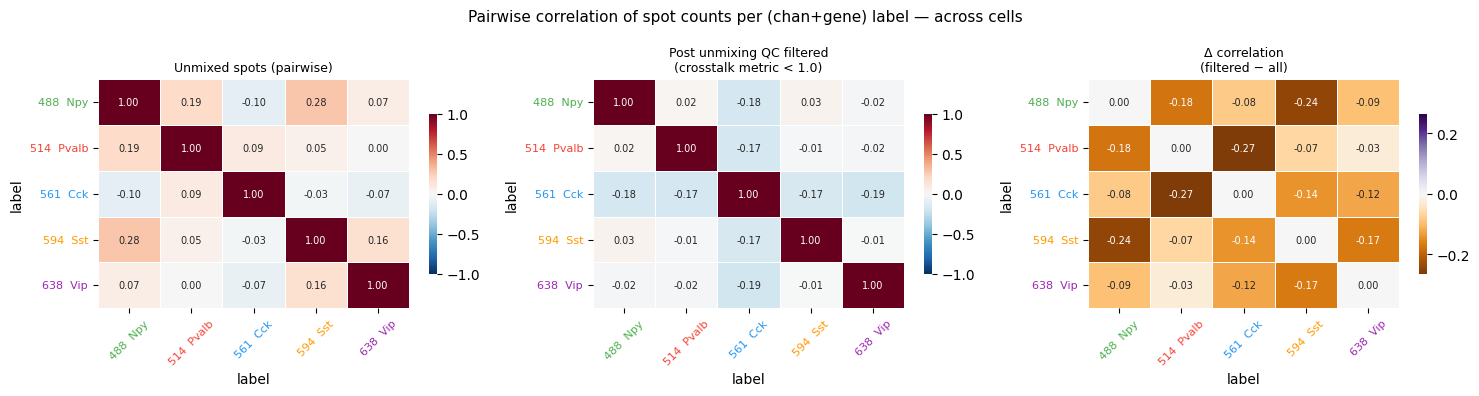

In [18]:

# --- Pairwise correlation heatmap: spot counts per (chan+gene) label, correlated across cells ---
import seaborn as sns

CROSSTALK_THRESH = 1.0

df = unmixed_spots_scored.copy()
df["label"] = df["unmixed_chan"].astype(str) + "  " + df["unmixed_gene"].astype(str)
df_filt = df[df["crosstalk_score"] < CROSSTALK_THRESH]

# Respect CHAN_ORDER for label ordering
label_order = []
for ch in CHAN_ORDER:
    labels_for_ch = sorted(df.loc[df["unmixed_chan"] == ch, "label"].unique())
    label_order.extend(labels_for_ch)

def spot_count_corr(df_, labels):
    """Build cell × label count matrix, then correlate columns (labels) across cells."""
    counts = (
        df_.groupby(["cell_id", "label"]).size()
        .unstack(fill_value=0)
        .reindex(columns=labels, fill_value=0)
    )
    return counts.corr()

corr_all  = spot_count_corr(df,      label_order)
corr_filt = spot_count_corr(df_filt, label_order)
corr_delta = corr_filt - corr_all   # positive = correlation increased after filtering

tick_colors = [CHAN_COLORS.get(lbl.split("  ")[0].strip(), "grey") for lbl in label_order]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Pairwise correlation of spot counts per (chan+gene) label — across cells", fontsize=11)

panels = [
    (axes[0], corr_all,   "RdBu_r", -1, 1,    "Unmixed spots (pairwise)"),
    (axes[1], corr_filt,  "RdBu_r", -1, 1,    f"Post unmixing QC filtered\n(crosstalk metric < {CROSSTALK_THRESH})"),
    (axes[2], corr_delta, "PuOr",   None, None, "Δ correlation\n(filtered − all)"),
]

for ax, corr, cmap, vmin, vmax, title in panels:
    delta_abs = corr_delta.abs().values
    center = 0
    if vmin is None:
        lim = max(delta_abs[~np.isnan(delta_abs)].max(), 0.01)
        vmin, vmax = -lim, lim
    sns.heatmap(
        corr, ax=ax,
        vmin=vmin, vmax=vmax, center=center,
        cmap=cmap,
        annot=True, fmt=".2f", annot_kws={"size": 7},
        linewidths=0.4, linecolor="white",
        xticklabels=label_order, yticklabels=label_order,
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(title, fontsize=9)
    for tick, color in zip(ax.get_xticklabels(), tick_colors):
        tick.set_color(color); tick.set_fontsize(8)
    for tick, color in zip(ax.get_yticklabels(), tick_colors):
        tick.set_color(color); tick.set_fontsize(8)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


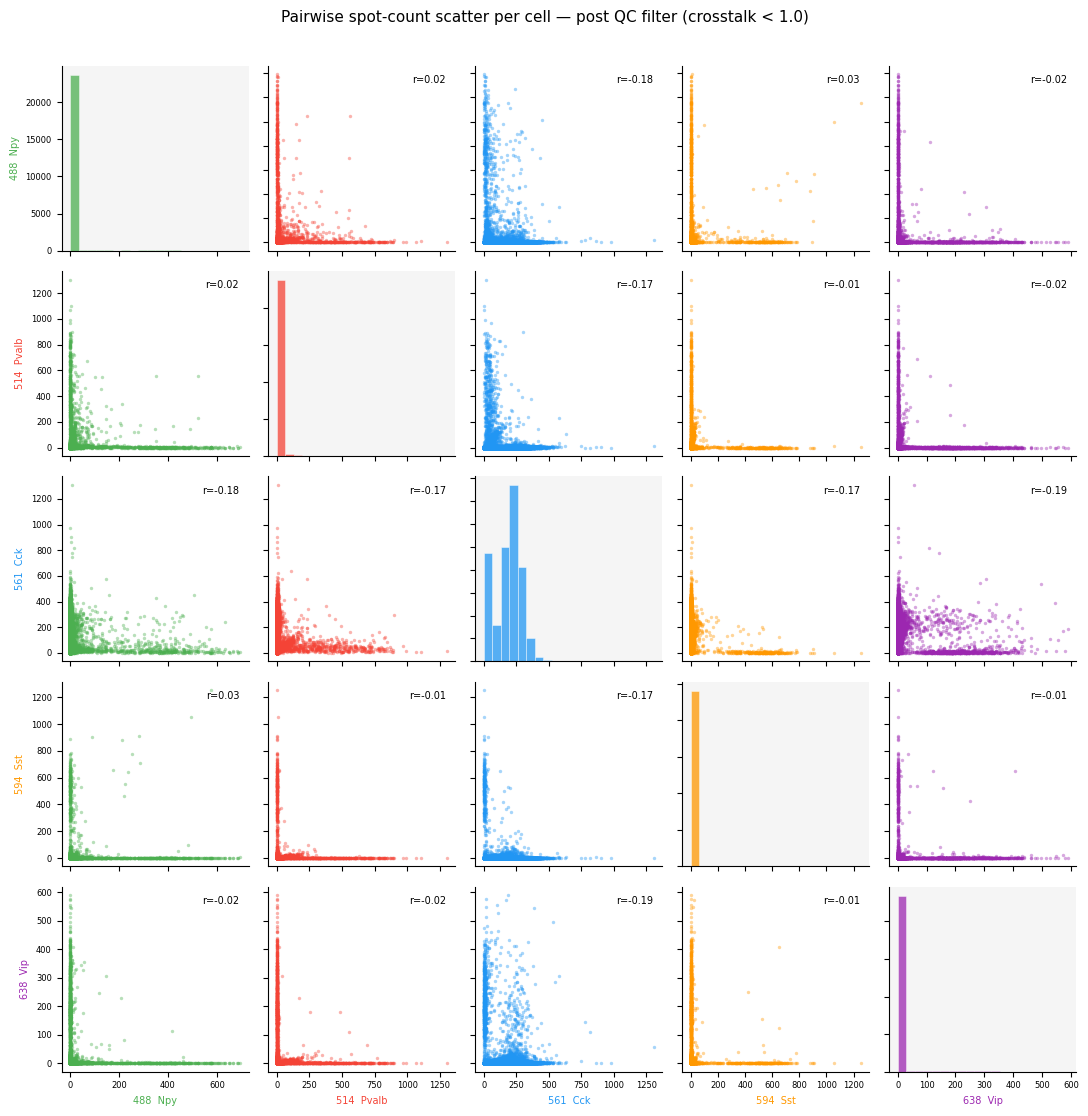

In [21]:

# --- Pairwise scatter: spot counts per cell, post-QC filter only ---
CROSSTALK_THRESH = 1.0

df = unmixed_spots_scored.copy()
df["label"] = df["unmixed_chan"].astype(str) + "  " + df["unmixed_gene"].astype(str)
df_filt = df[df["crosstalk_score"] < CROSSTALK_THRESH]

label_order = []
for ch in CHAN_ORDER:
    labels_for_ch = sorted(df.loc[df["unmixed_chan"] == ch, "label"].unique())
    label_order.extend(labels_for_ch)

# cell × label count matrix (filtered)
counts_filt = (
    df_filt.groupby(["cell_id", "label"]).size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

n = len(label_order)
fig, axes = plt.subplots(n, n, figsize=(n * 2.2, n * 2.2))
fig.suptitle(
    f"Pairwise spot-count scatter per cell — post QC filter (crosstalk < {CROSSTALK_THRESH})",
    fontsize=11, y=1.01,
)

for i, row_label in enumerate(label_order):
    for j, col_label in enumerate(label_order):
        ax = axes[i, j]
        color = CHAN_COLORS.get(col_label.split("  ")[0].strip(), "grey")

        if i == j:
            # diagonal: histogram of this label's counts
            ax.hist(counts_filt[row_label], bins=20, color=color, alpha=0.75, edgecolor="white", linewidth=0.4)
            ax.set_facecolor("#f5f5f5")
        else:
            x = counts_filt[col_label]
            y = counts_filt[row_label]
            r = x.corr(y)
            ax.scatter(x, y, s=6, alpha=0.4, color=color, linewidths=0)
            ax.text(0.95, 0.95, f"r={r:.2f}", transform=ax.transAxes,
                    ha="right", va="top", fontsize=7,
                    color="black" if abs(r) < 0.7 else "crimson")

        # axis labels on edges only
        if i == n - 1:
            ax.set_xlabel(col_label, fontsize=7,
                          color=CHAN_COLORS.get(col_label.split("  ")[0].strip(), "grey"))
        else:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        if j == 0:
            ax.set_ylabel(row_label, fontsize=7,
                          color=CHAN_COLORS.get(row_label.split("  ")[0].strip(), "grey"))
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        ax.tick_params(labelsize=6)
        ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()
